In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
class VGG16Classifier(nn.Module):
    def __init__(self, num_classes=2, freeze_features=True):
        super().__init__()
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if freeze_features:
            for param in self.vgg16.features.parameters():
                param.requires_grad = False

        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.vgg16(x)

checkpoint_path = '/home/vandrade/src/notebooks/cross_dataset_morphs/checkpoints/stylegan2-classifier/best_vgg16_weights_stylegan2.pt'
model = VGG16Classifier(num_classes=2, freeze_features=True).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))

<All keys matched successfully>

# MipGan 2

### 1073 morphs & 367 reais

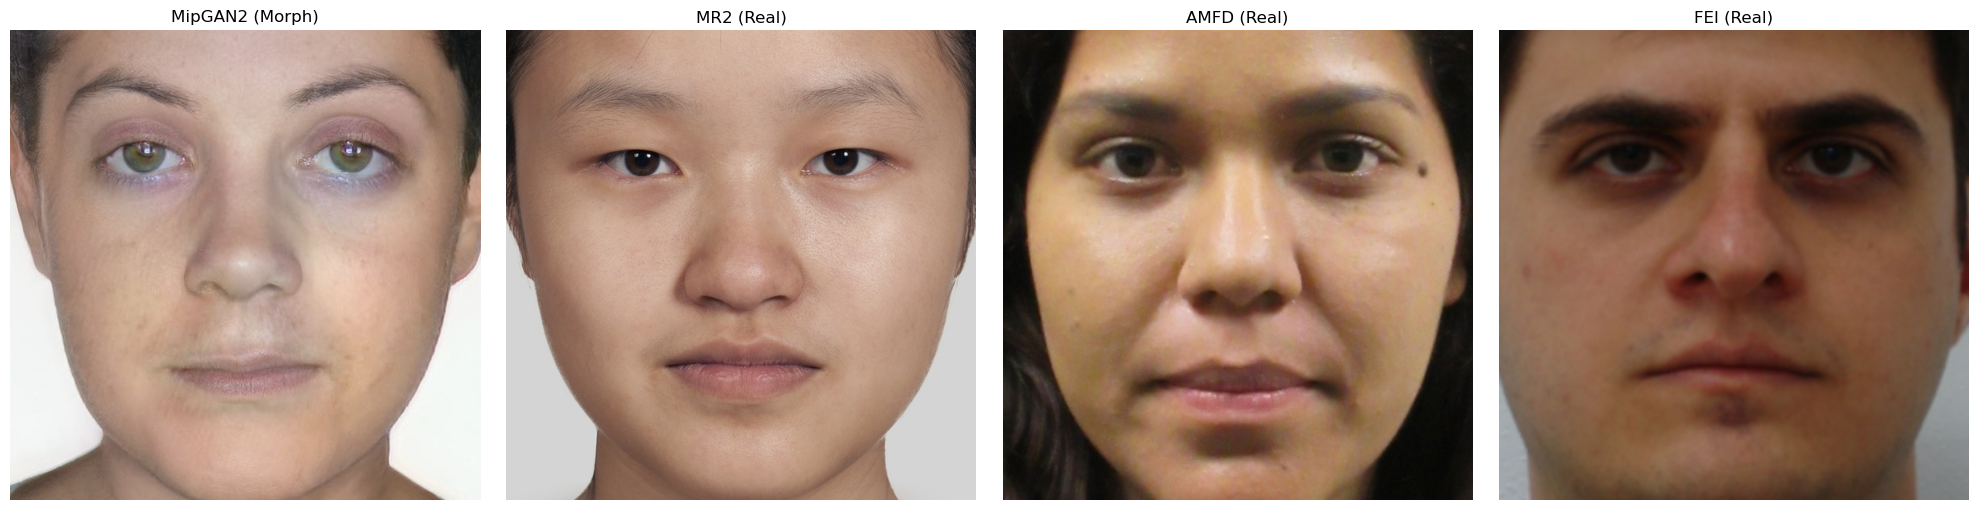

In [15]:
paths = [
    "/home/vandrade/data/imagens_morphs_reais_centercrop/mipgan2/001_03_719_03_0.3_mipgan2.jpg",
    "/home/vandrade/data/MR2_crop/af01.jpg",
    "/home/vandrade/data/AMFD_crop/NF-1022.jpg",
    "/home/vandrade/data/FEI_face_database_crop/1-11.jpg"
]

titles = ["MipGAN2 (Morph)", "MR2 (Real)", "AMFD (Real)", "FEI (Real)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, path in enumerate(paths):
    try:
        img = Image.open(path).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(titles[i], fontsize=12)
        axes[i].axis('off')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Erro ao carregar\n{path.split('/')[-2]}", 
                     ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [16]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

mip2_real_set = datasets.ImageFolder(root='/home/vandrade/data/cross_dataset_morphs/mipgan2_reais', transform=transformer_vgg16)
mip2_real_loader = DataLoader(dataset=mip2_real_set, batch_size=32, shuffle=False)

print(f"classes: {mip2_real_set.classes}")

classes: ['fake', 'real']


Acurácia Balanceada: 0.6822


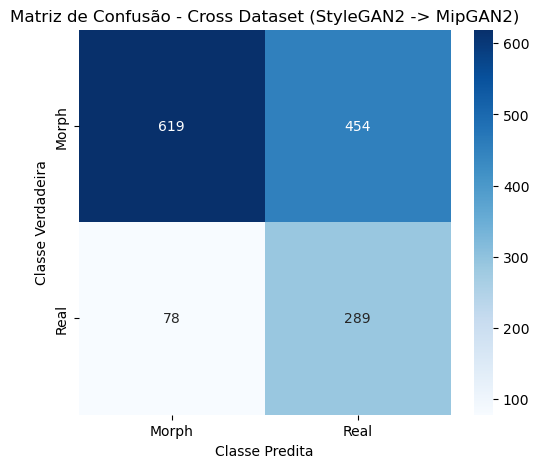

In [17]:
model.eval()

all_mip2_preds = []
all_mip2_targets = []

with torch.inference_mode():
    for X, y in mip2_real_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_mip2_preds.extend(preds.cpu().numpy())
        all_mip2_targets.extend(y.cpu().numpy())

bal_acc_mip2 = balanced_accuracy_score(all_mip2_targets, all_mip2_preds)
print(f"Acurácia Balanceada: {bal_acc_mip2:.4f}")

cm = confusion_matrix(all_mip2_targets, all_mip2_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Morph', 'Real'], 
            yticklabels=['Morph', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe Verdadeira')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> MipGAN2)')
plt.show()

# StyleGan3

### 1073 morphs & 367 reais

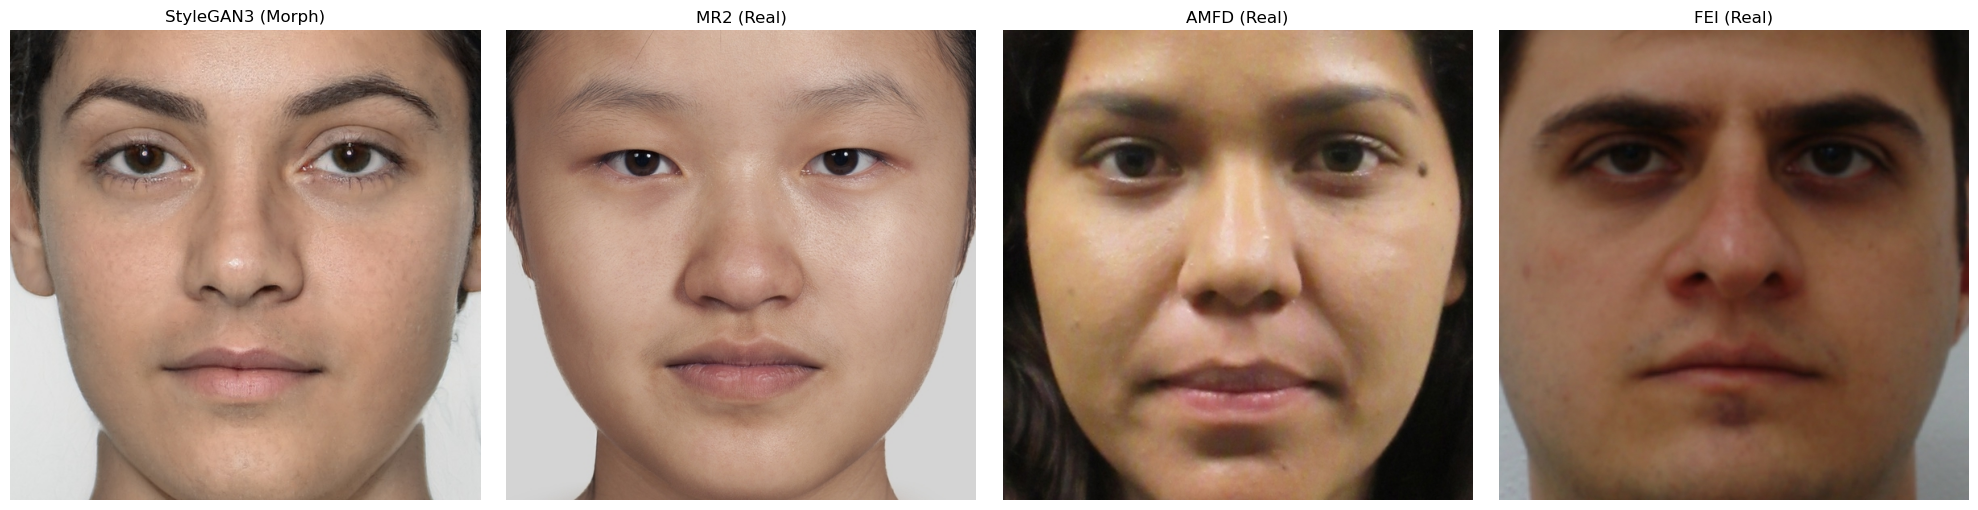

In [18]:
paths = [
    "/home/vandrade/data/imagens_morphs_reais_centercrop/stylegan3/001_03_719_03_0.3_stylegan3.jpg",
    "/home/vandrade/data/MR2_crop/af01.jpg",
    "/home/vandrade/data/AMFD_crop/NF-1022.jpg",
    "/home/vandrade/data/FEI_face_database_crop/1-11.jpg"
]

titles = ["StyleGAN3 (Morph)", "MR2 (Real)", "AMFD (Real)", "FEI (Real)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, path in enumerate(paths):
    try:
        img = Image.open(path).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(titles[i], fontsize=12)
        axes[i].axis('off')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Erro ao carregar\n{path.split('/')[-2]}", 
                     ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
transformer_vgg16 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

stg3_real_set = datasets.ImageFolder(root='/home/vandrade/data/cross_dataset_morphs/stylegan3_reais', transform=transformer_vgg16)
stg3_real_loader = DataLoader(dataset=stg3_real_set, batch_size=32, shuffle=False)

print(f"classes: {stg3_real_set.classes}")

classes: ['fake', 'real']


Acurácia Balanceada: 0.6253


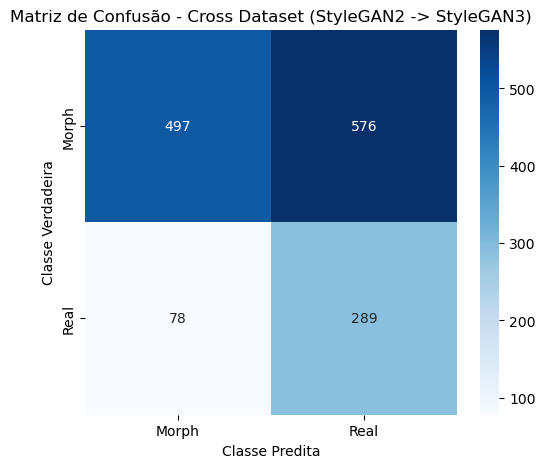

In [20]:
model.eval()

all_stg3_preds = []
all_stg3_targets = []

with torch.inference_mode():
    for X, y in stg3_real_loader:
        X,y = X.to(device), y.to(device)
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_stg3_preds.extend(preds.cpu().numpy())
        all_stg3_targets.extend(y.cpu().numpy())

bal_acc_stg3 = balanced_accuracy_score(all_stg3_targets, all_stg3_preds)
print(f"Acurácia Balanceada: {bal_acc_stg3:.4f}")

cm = confusion_matrix(all_stg3_targets, all_stg3_preds, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Morph', 'Real'], 
            yticklabels=['Morph', 'Real'])
plt.xlabel('Classe Predita')
plt.ylabel('Classe Verdadeira')
plt.title('Matriz de Confusão - Cross Dataset (StyleGAN2 -> StyleGAN3)')
plt.show()

In [21]:
import json
cross_data_stylegan2 = {
    "cross_mip2": bal_acc_mip2,
    "cross_stg3": bal_acc_stg3
}

with open('metrics_cross_stylegan2.json', 'w') as arquivo:
    json.dump(cross_data_stylegan2, arquivo)